# Output-Transformer TFiLM LSTM — Local Eval

Evaluates models trained by [`train_lstm_output_transformer_tfilm.ipynb`](train_lstm_output_transformer_tfilm.ipynb)
(`OutputTransformerTFiLMLSTM`). Same grey-box recipe as
[`eval_lstm_output_transformer.ipynb`](eval_lstm_output_transformer.ipynb), **plus**
the exported GR curve is fed back in as *continuous, time-varying* conditioning:

```
dry ──(× exported GR gain)──► amplitude-matched input ──►┐
                                                          ├─► [GR-conditioned LSTM] ──► wet
exported GR curve (dB) ───────────────────────────────────┘   (TVFiLM + concat)
```

- **Input**: amplitude-matched dry (`dry · 10**(gr_db/20)` from exported GR curves)
- **Conditioning**: the same sample-aligned `gr_db` curve, via block-wise `TVFiLMMod`
  (`use_tvfilm`) and/or sample-rate concat to the LSTM input (`concat_gr`)
- **Target**: wet audio
- **Stateful inference**: pre-roll warm-up; whole-song streaming carries both LSTM
  states (`TVFiLMMod` is stateless — no extra conditioning state)
- **Metrics**: ESR, MAE, MSE, MR-STFT, … via `src.losses.compute_all_losses`

> Requirements: `uv sync` at repo root, plus a local `./nablafx/` clone (for
> `TVFiLMMod`). Run after the Colab run dir has synced to Drive.


In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import gc, glob, json, os, sys, types, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# model_tfilm imports nablafx (TVFiLMMod). Stub the unused `rational` /
# `frechet_audio_distance` import-chain deps so `from nablafx...` doesn't drag in
# broken wheels — identical to the train notebook's cell 0.
_rational = types.ModuleType("rational")
_rational.torch = types.ModuleType("rational.torch")
_rational.torch.Rational = type("Rational", (), {})
sys.modules.setdefault("rational", _rational)
sys.modules.setdefault("rational.torch", _rational.torch)
_fad = types.ModuleType("frechet_audio_distance")
_fad.FrechetAudioDistance = type("FrechetAudioDistance", (), {})
sys.modules.setdefault("frechet_audio_distance", _fad)

REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(REPO_ROOT))                       # raw ./nablafx/ clone
sys.path.insert(0, str(REPO_ROOT / "06_output"))
sys.path.insert(0, str(REPO_ROOT / "03_initial_GR_pred"))

from amplitude_match import GR_DB_MIN, GR_DB_MAX, amplitude_match
from model_tfilm import OutputTransformerTFiLMLSTM
from splits import SplitManifest
from system import _detach_state, esr_metric
from eval_helpers import (
    _checkpoint_sort_key, _find_hparams_json, _pair_num_frames,
    _read_dry_wet_segment, _weighted_average_metric_rows, latest_best_checkpoint,
    list_runs, plot_loss_curves, wet_dir_for_setting,
)
from src.losses import compute_all_losses as compute_audio_losses

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/output_transformer_tfilm_runs"
DEVICE = "cpu"

print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"GR clamp: [{GR_DB_MIN}, {GR_DB_MAX}] dB")


/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu
GR clamp: [-30.0, 5.0] dB


In [2]:
# ── 1. List available GR-conditioned (TFiLM) output-transformer runs ──

MODEL_TYPE = "sample_rate_windowed_lstm"   # hparams model_type (shared with the non-TFiLM variant)

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, f"No runs in {RUNS_DIR}"
available_models_df = runs_df[runs_df["type"] == MODEL_TYPE].copy()
if available_models_df.empty:
    # older runs may only have `approach` in hparams — fall back to folder name tag
    available_models_df = runs_df[runs_df["run"].str.contains("tfilm", case=False, na=False)].copy()
assert not available_models_df.empty, (
    f"No '{MODEL_TYPE}' runs in {RUNS_DIR} — train with train_lstm_output_transformer_tfilm.ipynb first."
)

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available TFiLM output-transformer runs: {len(available_models_df)}")
display(available_models_df[display_cols])


Available TFiLM output-transformer runs: 2


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
0,ot_lstm_20260618_104059_lstm_output_transforme...,sample_rate_windowed_lstm,6,0.096877,4,best-003-1904.ckpt,2026-06-18 10:43:48.042374849
1,ot_lstm_20260618_105909_lstm_output_transforme...,sample_rate_windowed_lstm,31,0.071623,4,best-024-11900.ckpt,2026-06-18 11:01:55.239451885


In [3]:
# ── 2. Select run, checkpoint and split manifest ─────────────────────

# Leave as None to auto-pick the most recently modified matching run.
SELECTED_RUN_NAME: str | None = None

if not SELECTED_RUN_NAME:
    selected_run = available_models_df.iloc[-1]   # list_runs sorts by mtime asc
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

with open(HPARAMS_PATH) as f:
    HP = json.load(f)
SPLIT = SplitManifest.load(os.path.join(RUN_DIR, "split_manifest.json"))


def _pairs_from_keys(keys) -> list[tuple[str, str]]:
    return [tuple(k.split("::")) for k in sorted(keys)]   # (song, setting)


VAL_PAIRS = _pairs_from_keys(SPLIT.val_pair_keys)
TEST_PAIRS = _pairs_from_keys(SPLIT.test_pair_keys)

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")
print(f"Val pairs      : {len(VAL_PAIRS)}  ({SPLIT.val_songs} x all settings)")
print(f"Test pairs     : {len(TEST_PAIRS)}  ({SPLIT.test_songs} x {SPLIT.test_settings})")


Selected run   : ot_lstm_20260618_105909_lstm_output_transformer_gr_tfilm
Eval checkpoint: best-024-11900.ckpt
Best val loss  : 0.071623
Val pairs      : 10  (['Ecstasy'] x all settings)
Test pairs     : 4  (['Air', 'AncoraQui'] x ['threshold_-12_attack_10_release_0.4_ratio_10', 'threshold_-12_attack_1_release_0.1_ratio_2'])


In [4]:
# ── 3. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")


Selected run   : ot_lstm_20260618_105909_lstm_output_transformer_gr_tfilm
Eval checkpoint: best-024-11900.ckpt
Checkpoints    :
  last.ckpt                               0.08 MB
  best-007-3808.ckpt                      0.08 MB
  best-013-6664.ckpt                      0.08 MB
  best-024-11900.ckpt                     0.08 MB <-- eval


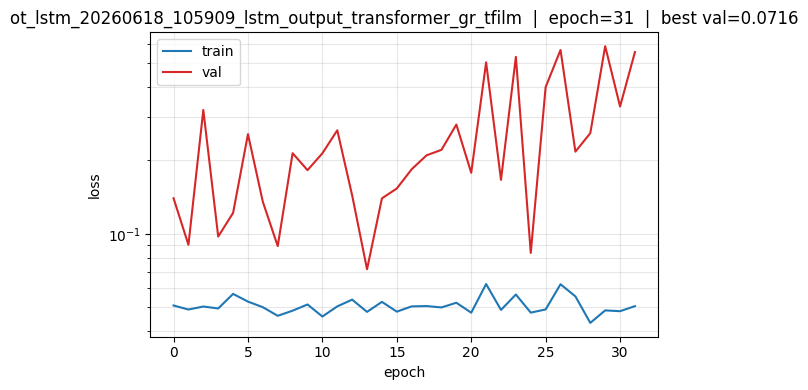

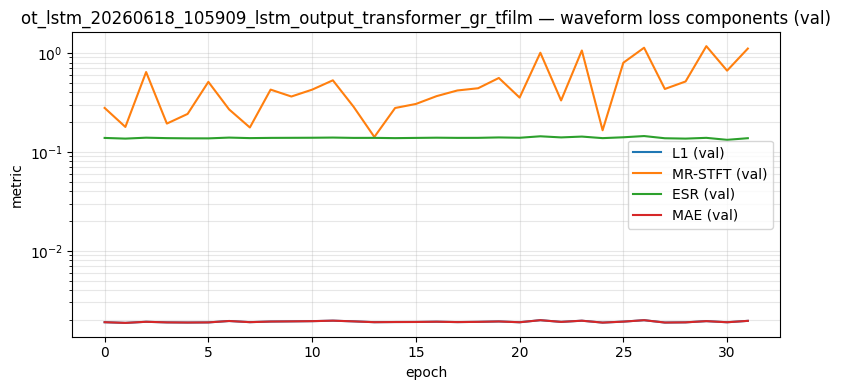

In [5]:
# ── 4. Loss curves (total + time / freq components) ─────────────────

_ = plot_loss_curves(RUN_DIR)

csv_path = Path(RUN_DIR) / "csv" / "metrics.csv"
if csv_path.exists():
    _df = pd.read_csv(csv_path)
    comp_cols = [
        ("loss/val_td", "L1 (val)"),
        ("loss/val_fd", "MR-STFT (val)"),
        ("esr/val", "ESR (val)"),
        ("mae/val", "MAE (val)"),
    ]
    if any(c in _df.columns for c, _ in comp_cols):
        fig, ax = plt.subplots(figsize=(8, 4))
        for col, label in comp_cols:
            if col in _df.columns:
                rows = _df.dropna(subset=[col])[["epoch", col]]
                if len(rows):
                    ax.plot(rows["epoch"], rows[col], label=label, lw=1.5)
        ax.set_xlabel("epoch")
        ax.set_ylabel("metric")
        ax.set_yscale("log")
        ax.grid(alpha=0.3, which="both")
        ax.legend()
        ax.set_title(f"{RUN_NAME} — waveform loss components (val)")
        plt.tight_layout()
        plt.show()


In [6]:
# ── 5. Checkpoint loading (OutputTransformerTFiLMLSTM) ───────────────

def load_model_from_ckpt(ckpt_path, hparams_path=None):
    # Build from hparams.json and load weights (strip Lightning 'model.' prefix).
    hparams_path = hparams_path or _find_hparams_json(ckpt_path)
    with open(hparams_path) as f:
        hp = json.load(f)
    assert hp.get("model_type") == MODEL_TYPE, hp.get("model_type")
    m = hp["model"]
    model = OutputTransformerTFiLMLSTM(
        window=int(hp["window"]),
        encoder_channels=int(m["encoder_channels"]),
        hidden_size=int(m["hidden_size"]),
        mid_channels=int(m["mid_channels"]),
        num_lstm_layers=int(m["num_lstm_layers"]),
        output_mode=str(m.get("output_mode", "residual_add")),
        out_activation=str(m.get("out_activation", "none")),
        concat_gr=bool(m.get("concat_gr", True)),
        use_tvfilm=bool(m.get("use_tvfilm", True)),
        tvfilm_block_size=int(m.get("tvfilm_block_size", 256)),
        gr_cond_channels=int(m.get("gr_cond_channels", 8)),
        gr_use_delta=bool(m.get("gr_use_delta", True)),
    )
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    model.load_state_dict({k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")})
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(
        f"Loaded {n_params:,}-param OutputTransformerTFiLMLSTM  "
        f"(window={model.window}, output_mode={model.output_mode}, "
        f"layers={model.num_lstm_layers}, concat_gr={model.concat_gr}, "
        f"use_tvfilm={model.use_tvfilm})"
    )
    return model, hp


MODEL, HP = load_model_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
WINDOW = int(HP["window"])
SEG_LEN = int(HP["segment_len"])
SR = int(HP["sample_rate"])


Loaded 4,393-param OutputTransformerTFiLMLSTM  (window=64, output_mode=residual_add, layers=2, concat_gr=True, use_tvfilm=True)


In [7]:
# ── 6. Prediction & visualisation (stateful, amplitude-matched + GR) ─
# Single-window prediction warms both LSTM states with a `pre_roll_sec`
# context in the SAME causal forward pass, then crops to the requested window.
# The exported GR curve is passed alongside the matched input as the model's
# continuous conditioning signal (sample-aligned to the model output).

DEFAULT_PRE_ROLL_SEC = 10.0


def pair_paths(setting: str, song: str) -> tuple[str, str, str]:
    dry = os.path.join(DATA_ROOT, "processed_normalized", f"{song}_UnmasteredWAV.wav")
    wet = os.path.join(wet_dir_for_setting(DATA_ROOT, setting), f"{song}-exported.wav")
    gr = os.path.join(DATA_ROOT, "gr_curves", setting, f"{song}.pt")
    return dry, wet, gr


def _load_gr_segment(gr_path: str, start: int, stop: int) -> torch.Tensor:
    gr_db = torch.load(gr_path, map_location="cpu", weights_only=False)["gr_db"].float()
    return gr_db[..., start:stop]


def _build_model_input(dry: torch.Tensor, gr_db: torch.Tensor, window: int) -> torch.Tensor:
    # dry/gr_db aligned [1, T] -> model input [1, 1, T] with left context.
    amp = amplitude_match(dry, gr_db)
    return amp.unsqueeze(0)


def _gr_cond(gr_db: torch.Tensor, window: int) -> torch.Tensor:
    # Conditioning curve aligned to the model output: drop the window-1 left
    # context that the windowed conv consumes -> [1, 1, T-(window-1)].
    return gr_db[..., window - 1:].unsqueeze(0)


@torch.no_grad()
def predict_wet_segment(setting, song, start_sec=0.0, duration_sec=6.0,
                        pre_roll_sec=DEFAULT_PRE_ROLL_SEC, model=None):
    model = model or MODEL
    sr = SR
    w = WINDOW
    dry_path, wet_path, gr_path = pair_paths(setting, song)

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    context_start = max(0, start - int(round(pre_roll_sec * sr)))
    offset = start - context_start

    ctx_lo = max(0, context_start - (w - 1))
    dry_ctx, wet_ctx = _read_dry_wet_segment(dry_path, wet_path, ctx_lo, stop, sr)
    gr_ctx = _load_gr_segment(gr_path, ctx_lo, stop)
    n = min(dry_ctx.shape[-1], gr_ctx.shape[-1], wet_ctx.shape[-1])
    dry_ctx, gr_ctx, wet_ctx = dry_ctx[..., :n], gr_ctx[..., :n], wet_ctx[..., :n]

    inp = _build_model_input(dry_ctx, gr_ctx, w).to(DEVICE)
    gr_in = _gr_cond(gr_ctx, w).to(DEVICE)
    pred_full, _ = model(inp, gr_in, state=None, return_state=True)

    crop_start = start - ctx_lo - (w - 1)
    crop_stop = crop_start + min(stop - start, pred_full.shape[-1] - crop_start)
    sl = slice(crop_start, crop_stop)
    pred = pred_full[..., sl].squeeze(0).cpu()
    amp = amplitude_match(dry_ctx, gr_ctx)[..., sl].squeeze(0).cpu()
    wet = wet_ctx[..., sl].squeeze(0).cpu()
    dry = dry_ctx[..., sl].squeeze(0).cpu()
    err = (pred - wet).squeeze().numpy()

    losses_pred = compute_audio_losses(pred.unsqueeze(0), wet.unsqueeze(0))
    losses_base = compute_audio_losses(amp.unsqueeze(0), wet.unsqueeze(0))

    t_len = pred.shape[-1]
    return {
        "song": song, "setting": setting,
        "sample_rate": sr, "start_sec": start_sec, "duration_sec": t_len / sr,
        "pre_roll_sec": offset / sr, "time": np.arange(t_len) / sr,
        "dry": dry.squeeze().numpy(), "amp": amp.squeeze().numpy(),
        "wet": wet.squeeze().numpy(), "pred": pred.squeeze().numpy(),
        "error": err,
        "mae": float(np.mean(np.abs(err))),
        "esr": float(esr_metric(wet.unsqueeze(0), pred.unsqueeze(0))),
        "losses_pred": losses_pred, "losses_base": losses_base,
    }


def visualize_prediction(setting=None, song=None, start_sec=30.0, duration_sec=6.0,
                         pre_roll_sec=DEFAULT_PRE_ROLL_SEC, title=None):
    song = song or TEST_PAIRS[0][0]
    setting = setting or TEST_PAIRS[0][1]
    seg = predict_wet_segment(setting, song, start_sec, duration_sec, pre_roll_sec)

    t = seg["time"]
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True,
                             gridspec_kw={"height_ratios": [1, 2, 1]})

    axes[0].plot(t, seg["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, seg["amp"], label="amp-matched (baseline)", lw=0.6, color="gray", alpha=0.5)
    axes[1].plot(t, seg["wet"], label="target (wet)", lw=1.0, color="#1f77b4")
    axes[1].plot(t, seg["pred"], label="prediction", lw=0.9, color="#d62728", alpha=0.85)
    axes[1].set_ylabel("amp"); axes[1].legend(loc="lower right"); axes[1].set_ylim(-1.05, 1.05)
    axes[1].grid(alpha=0.3)

    axes[2].plot(t, seg["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("error"); axes[2].set_xlabel("time (s)"); axes[2].grid(alpha=0.3)

    lp, lb = seg["losses_pred"], seg["losses_base"]
    fig.suptitle(title or (
        f"{seg['song']}  |  {seg['setting']}\n"
        f"pre-roll={seg['pre_roll_sec']:.1f}s  "
        f"MAE pred {lp['MAE (L1)']:.4f} (baseline {lb['MAE (L1)']:.4f})  "
        f"ESR pred {lp['ESR']:.4f} (baseline {lb['ESR']:.4f})"
    ), fontsize=10)
    plt.tight_layout(); plt.show()
    return seg


def settings_sweep(song=None, settings=None, start_sec=30.0, duration_sec=6.0,
                   pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    # Same song through every setting - grey-box generalisation across knobs.
    song = song or SPLIT.val_songs[0]
    settings = settings or SPLIT.all_settings
    segs = [predict_wet_segment(s, song, start_sec, duration_sec, pre_roll_sec) for s in settings]

    fig, axes = plt.subplots(len(segs), 1, figsize=(11, 1.8 * len(segs)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, s in zip(axes[:, 0], segs):
        ax.plot(s["time"], s["wet"], lw=1.0, color="#1f77b4", label="target")
        ax.plot(s["time"], s["pred"], lw=0.9, color="#d62728", alpha=0.85, label="prediction")
        ax.set_ylabel("amp", fontsize=8)
        lp = s["losses_pred"]
        ax.set_title(
            f"{s['setting']}  —  MAE {lp['MAE (L1)']:.4f}  ESR {lp['ESR']:.4f}",
            fontsize=8, loc="left",
        )
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(f"Settings sweep — {song} ({duration_sec:.0f}s @ {start_sec:.0f}s)", fontsize=11)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {
            "setting": s["setting"],
            "MAE pred": s["losses_pred"]["MAE (L1)"],
            "MAE baseline": s["losses_base"]["MAE (L1)"],
            "ESR pred": s["losses_pred"]["ESR"],
            "ESR baseline": s["losses_base"]["ESR"],
        }
        for s in segs
    ])
    display(df)
    return segs, df


## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the selection cell.

- `visualize_prediction(setting=..., song=...)` — any (setting, song); defaults to the first **test** pair.
- `settings_sweep(song=...)` — one song through all 10 settings (defaults to the val song). The per-setting MAE/ESR table is the headline generalisation result.


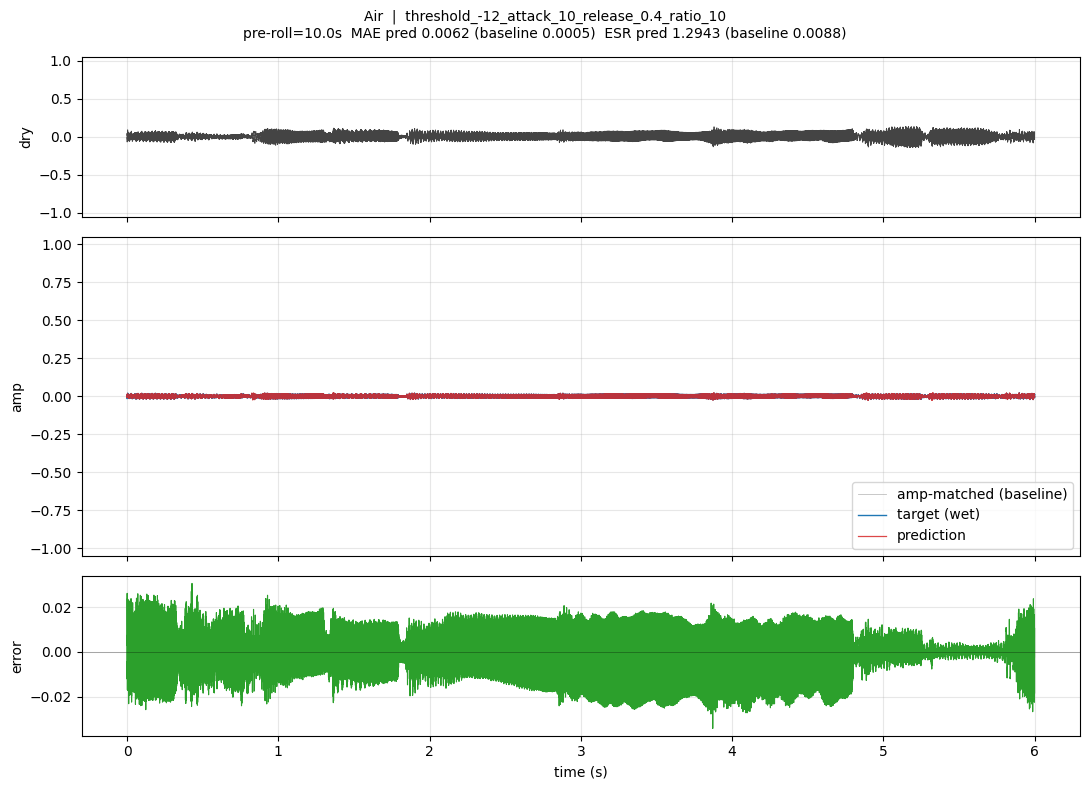

In [8]:
# Single prediction preview — held-out test song x lowest-threshold setting
song, setting = TEST_PAIRS[0]
_ = visualize_prediction(setting=setting, song=song, start_sec=30.0, duration_sec=6.0)


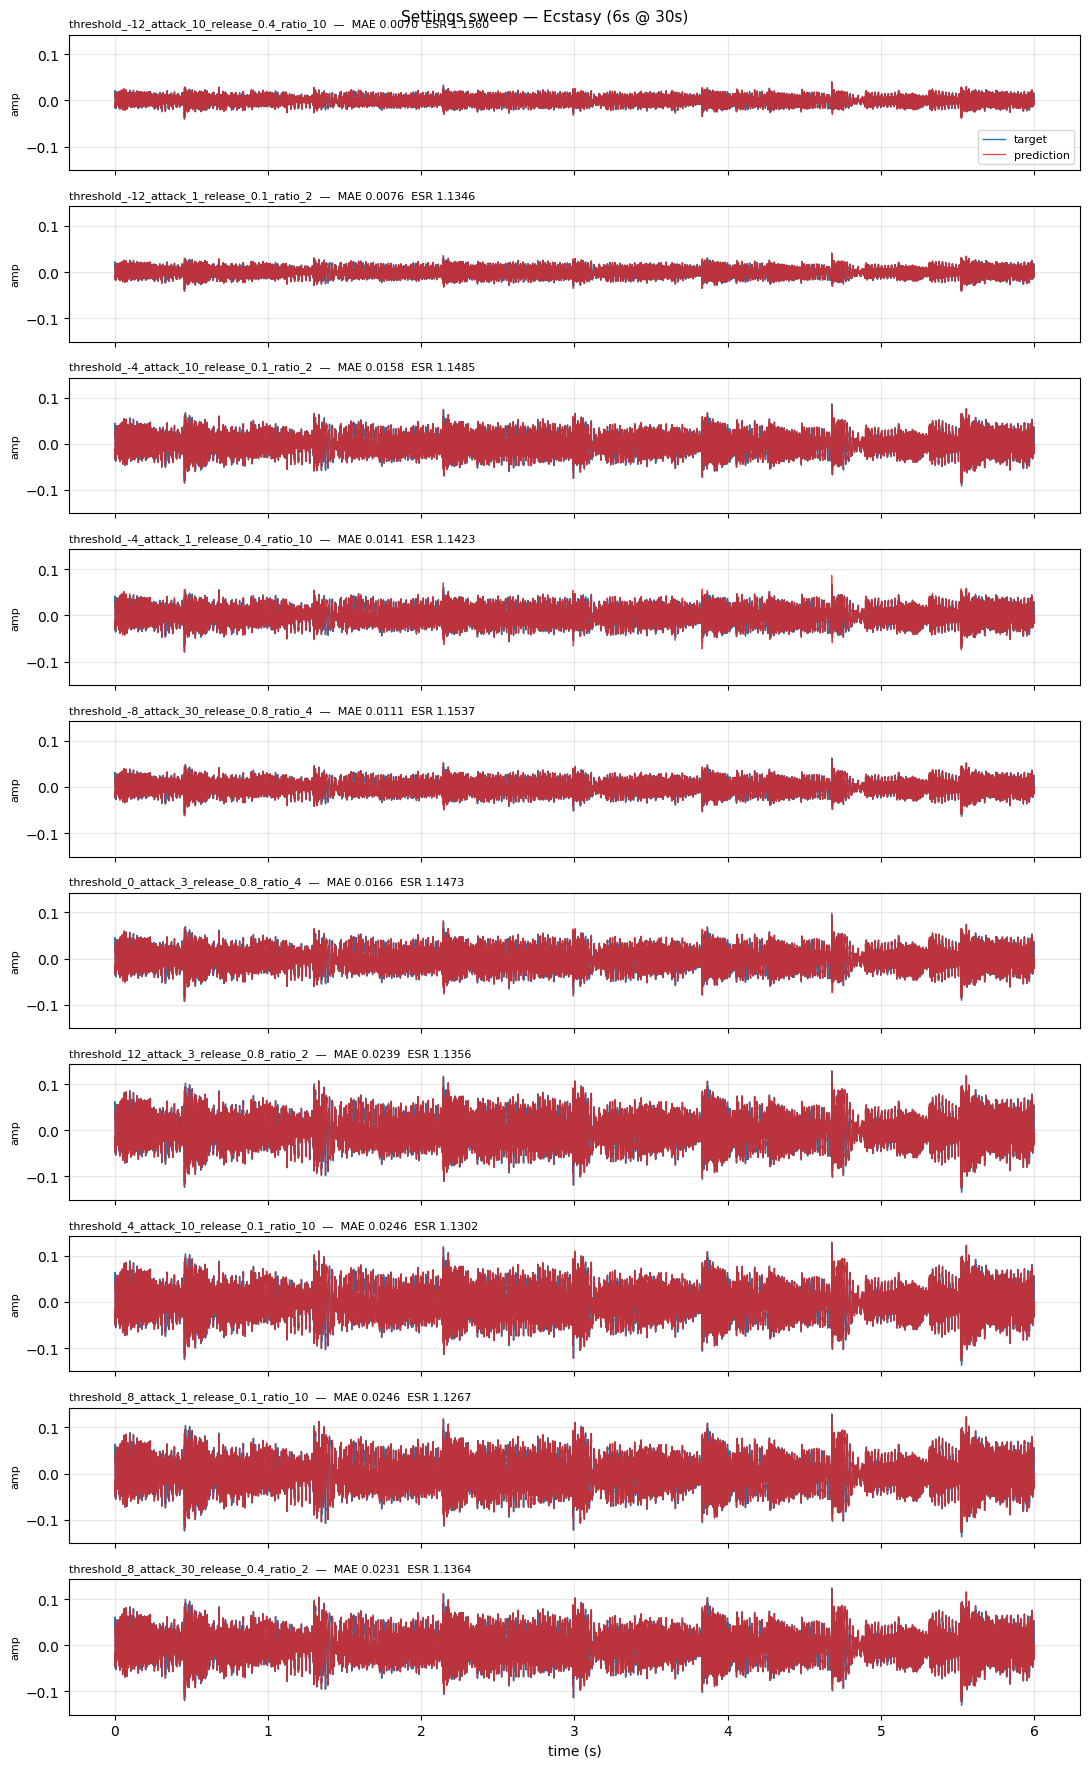

,setting,MAE pred,MAE baseline,ESR pred,ESR baseline
0,threshold_-12_attack_10_release_0.4_ratio_10,0.007014,0.000787,1.156046,0.021432
1,threshold_-12_attack_1_release_0.1_ratio_2,0.007553,0.000853,1.134643,0.021017
2,threshold_-4_attack_10_release_0.1_ratio_2,0.015844,0.001642,1.148454,0.019320
3,threshold_-4_attack_1_release_0.4_ratio_10,0.014109,0.001539,1.142250,0.020421
4,threshold_-8_attack_30_release_0.8_ratio_4,0.011054,0.001134,1.153743,0.019044
5,threshold_0_attack_3_release_0.8_ratio_4,0.016590,0.001687,1.147265,0.018601
6,threshold_12_attack_3_release_0.8_ratio_2,0.023909,0.002412,1.135608,0.018567
7,threshold_4_attack_10_release_0.1_ratio_10,0.024641,0.002488,1.130217,0.018554
8,threshold_8_attack_1_release_0.1_ratio_10,0.024595,0.002482,1.126738,0.018503
9,threshold_8_attack_30_release_0.4_ratio_2,0.023119,0.002334,1.136374,0.018598


In [9]:
# Settings sweep: validation song through all 10 settings
sweep_segs, sweep_df = settings_sweep(start_sec=30.0, duration_sec=6.0)


In [ ]:
# ── 7. Audio metrics on val & test splits (TRUE stateful streaming) ──
# Streams each (song, setting) pair whole-song in chunks with BOTH LSTM
# states carried across chunks (matching TBPTT training); the GR curve is fed
# alongside each chunk. TVFiLMMod is stateless, so only the LSTM states carry.
# Also reports the amplitude-matched baseline (no LSTM) for comparison.

MAX_EVAL_PAIRS: int | None = None    # small int for a smoke test
STREAM_CHUNK_SEC = 10.0
SAVE_CHUNK_METRICS = False
metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]
baseline_cols = [f"{c} (baseline)" for c in metric_cols]
pred_cols = [f"{c} (pred)" for c in metric_cols]

sr = SR
w = WINDOW
chunk_samples = int(round(STREAM_CHUNK_SEC * sr))


@torch.no_grad()
def stream_pair_metrics(song: str, setting: str) -> list[dict]:
    # Stateful pass over a whole (song, setting) pair; per-chunk metric rows.
    dry_path, wet_path, gr_path = pair_paths(setting, song)
    total = _pair_num_frames(dry_path, wet_path, sr)
    gr_full = torch.load(gr_path, map_location="cpu", weights_only=False)["gr_db"].float()
    state = None
    rows = []
    for ci, o in enumerate(range(0, total, chunk_samples), start=1):
        stop = min(o + chunk_samples, total)
        lo = max(0, o - (w - 1))
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, lo, stop, sr)
        gr = gr_full[..., lo:stop]
        n = min(dry.shape[-1], gr.shape[-1], wet.shape[-1])
        if n < w:
            break
        dry, gr, wet = dry[..., :n], gr[..., :n], wet[..., :n]

        inp = _build_model_input(dry, gr, w).to(DEVICE)
        gr_in = _gr_cond(gr, w).to(DEVICE)
        pred, state = MODEL(inp, gr_in, state, return_state=True)
        state = _detach_state(state)

        # crop to the non-overlap region of this chunk (aligned to sample o);
        # clamp the upper bound to the available output length so the trailing
        # chunk (where pred is window-1 shorter than the read window) still aligns.
        crop_lo = o - lo
        crop_hi = crop_lo + min(stop - o, pred.shape[-1] - crop_lo)
        pred_c = pred[..., crop_lo:crop_hi].squeeze(0).cpu()
        wet_c = wet[..., crop_lo:crop_hi].squeeze(0).cpu()
        amp_c = amplitude_match(dry, gr)[..., crop_lo:crop_hi].squeeze(0).cpu()

        losses_pred = compute_audio_losses(pred_c.unsqueeze(0), wet_c.unsqueeze(0))
        losses_base = compute_audio_losses(amp_c.unsqueeze(0), wet_c.unsqueeze(0))
        L = wet_c.shape[-1]
        rows.append({
            "Chunk": ci, "Start (s)": o / sr, "Duration (s)": L / sr, "Frames": L,
            **{f"{k} (pred)": v for k, v in losses_pred.items()},
            **{f"{k} (baseline)": v for k, v in losses_base.items()},
        })
    return rows


split_rows, pair_rows = [], []
for split_name, split_pairs in (("validation", VAL_PAIRS), ("test", TEST_PAIRS)):
    if MAX_EVAL_PAIRS is not None:
        split_pairs = split_pairs[:MAX_EVAL_PAIRS]
    chunk_rows = []
    for i, (song, setting) in enumerate(split_pairs, start=1):
        print(f"[{split_name} {i}/{len(split_pairs)}] {song} / {setting}")
        rows = stream_pair_metrics(song, setting)
        chunk_rows += [{"Song": song, "Setting": setting, **r} for r in rows]
        pair_rows.append({
            "Split": split_name, "Song": song, "Setting": setting,
            "Duration (s)": sum(r["Frames"] for r in rows) / sr,
            **_weighted_average_metric_rows(rows, pred_cols),
            **_weighted_average_metric_rows(rows, baseline_cols),
        })
        gc.collect()
    total_frames = sum(r["Frames"] for r in chunk_rows)
    split_rows.append({
        "Split": split_name, "Pairs": len(split_pairs), "Chunks": len(chunk_rows),
        "Duration (s)": total_frames / sr,
        **_weighted_average_metric_rows(chunk_rows, pred_cols),
        **_weighted_average_metric_rows(chunk_rows, baseline_cols),
    })
    if SAVE_CHUNK_METRICS:
        chunk_path = Path(RUN_DIR) / f"eval_audio_metrics_{split_name}_chunks.csv"
        pd.DataFrame(chunk_rows).to_csv(chunk_path, index=False)
        print(f"Saved chunk metrics -> {chunk_path}")

pair_metrics_df = pd.DataFrame(pair_rows)
audio_metrics_df = pd.DataFrame(split_rows)
pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_pairs.csv", index=False)
audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics(.csv, _pairs.csv)")

display(pair_metrics_df)
display(audio_metrics_df)


[validation 1/10] Ecstasy / threshold_-12_attack_10_release_0.4_ratio_10
